In [1]:
import random
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download, snapshot_download

# PrithviWxC specific imports
from PrithviWxC.dataloaders.merra2_rollout import Merra2RolloutDataset, preproc
from PrithviWxC.dataloaders.merra2 import input_scalers, output_scalers, static_input_scalers
from PrithviWxC.model import PrithviWxC
from PrithviWxC.rollout import rollout_iter

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True
    device = torch.device("cuda")
    torch.cuda.manual_seed(42)
else:
    device = torch.device("cpu")

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

# Task & Time Variables
lead_time = 12 
input_time = -6 
time_range = ("2020-01-01T00:00:00", "2020-01-01T23:59:59")
positional_encoding = "fourier"

# Features & Padding
surface_vars = ["EFLUX", "GWETROOT", "HFLUX", "LAI", "LWGAB", "LWGEM", "LWTUP", "PS", "QV2M", "SLP", "SWGNT", "SWTNT", "T2M", "TQI", "TQL", "TQV", "TS", "U10M", "V10M", "Z0M"]
static_surface_vars = ["FRACI", "FRLAND", "FROCEAN", "PHIS"]
vertical_vars = ["CLOUD", "H", "OMEGA", "PL", "QI", "QL", "QV", "T", "U", "V"]
levels = [34.0, 39.0, 41.0, 43.0, 44.0, 45.0, 48.0, 51.0, 53.0, 56.0, 63.0, 68.0, 71.0, 72.0]
padding = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}
variable_names = surface_vars + [f'{var}_level_{level}' for var in vertical_vars for level in levels]

# Model settings
residual = "climate"
masking_mode = "both"
encoder_shifting = True
decoder_shifting = True
masking_ratio = 0.0

# ==========================================
# 2. DOWNLOAD DATA, CONFIGS, & WEIGHTS
# ==========================================
repo_id = "ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M"
rollout_repo_id = "ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M-rollout"
local_dir = "../data"

# Data and Climatology
surf_dir = Path("../data/merra-2")
vert_dir = Path("../data/merra-2")
surf_clim_dir = Path("../data/climatology")
vert_clim_dir = Path("../data/climatology")

snapshot_download(repo_id=repo_id, allow_patterns="merra-2/MERRA2_sfc_2020010[1].nc", local_dir=local_dir)
snapshot_download(repo_id=repo_id, allow_patterns="merra-2/MERRA_pres_2020010[1].nc", local_dir=local_dir)
snapshot_download(repo_id=repo_id, allow_patterns="climatology/climate_surface_doy00[1]*.nc", local_dir=local_dir)
snapshot_download(repo_id=repo_id, allow_patterns="climatology/climate_vertical_doy00[1]*.nc", local_dir=local_dir)

# Scalers & Configs
surf_in_scal_path = Path("../data/climatology/musigma_surface.nc")
vert_in_scal_path = Path("../data/climatology/musigma_vertical.nc")
surf_out_scal_path = Path("../data/climatology/anomaly_variance_surface.nc")
vert_out_scal_path = Path("../data/climatology/anomaly_variance_vertical.nc")

hf_hub_download(repo_id=repo_id, filename=f"climatology/{surf_in_scal_path.name}", local_dir=local_dir)
hf_hub_download(repo_id=repo_id, filename=f"climatology/{vert_in_scal_path.name}", local_dir=local_dir)
hf_hub_download(repo_id=repo_id, filename=f"climatology/{surf_out_scal_path.name}", local_dir=local_dir)
hf_hub_download(repo_id=repo_id, filename=f"climatology/{vert_out_scal_path.name}", local_dir=local_dir)
hf_hub_download(repo_id=rollout_repo_id, filename="config.yaml", local_dir=local_dir)

# Weights
weights_path = Path("../data/weights/prithvi.wxc.rollout.2300m.v1.pt")
hf_hub_download(repo_id=rollout_repo_id, filename=weights_path.name, local_dir="../data/weights")

# ==========================================
# 3. PREPARE DATALOADER & SCALERS
# ==========================================
dataset = Merra2RolloutDataset(
    time_range=time_range, lead_time=lead_time, input_time=input_time,
    data_path_surface=surf_dir, data_path_vertical=vert_dir,
    climatology_path_surface=surf_clim_dir, climatology_path_vertical=vert_clim_dir,
    surface_vars=surface_vars, static_surface_vars=static_surface_vars,
    vertical_vars=vertical_vars, levels=levels, positional_encoding=positional_encoding,
)
assert len(dataset) > 0, "There doesn't seem to be any valid data."

in_mu, in_sig = input_scalers(surface_vars, vertical_vars, levels, surf_in_scal_path, vert_in_scal_path)
output_sig = output_scalers(surface_vars, vertical_vars, levels, surf_out_scal_path, vert_out_scal_path)
static_mu, static_sig = static_input_scalers(surf_in_scal_path, static_surface_vars)

# ==========================================
# 4. INITIALIZE MODEL
# ==========================================
with open("../data/config.yaml", "r") as f:
    config = yaml.safe_load(f)

model = PrithviWxC(
    in_channels=config["params"]["in_channels"], input_size_time=config["params"]["input_size_time"],
    in_channels_static=config["params"]["in_channels_static"],
    input_scalers_mu=in_mu, input_scalers_sigma=in_sig, input_scalers_epsilon=config["params"]["input_scalers_epsilon"],
    static_input_scalers_mu=static_mu, static_input_scalers_sigma=static_sig, static_input_scalers_epsilon=config["params"]["static_input_scalers_epsilon"],
    output_scalers=output_sig**0.5,
    n_lats_px=config["params"]["n_lats_px"], n_lons_px=config["params"]["n_lons_px"],
    patch_size_px=config["params"]["patch_size_px"], mask_unit_size_px=config["params"]["mask_unit_size_px"],
    mask_ratio_inputs=masking_ratio, mask_ratio_targets=0.0,
    embed_dim=config["params"]["embed_dim"], n_blocks_encoder=config["params"]["n_blocks_encoder"],
    n_blocks_decoder=config["params"]["n_blocks_decoder"], mlp_multiplier=config["params"]["mlp_multiplier"],
    n_heads=config["params"]["n_heads"], dropout=config["params"]["dropout"], drop_path=config["params"]["drop_path"],
    parameter_dropout=config["params"]["parameter_dropout"], residual=residual, masking_mode=masking_mode,
    encoder_shifting=encoder_shifting, decoder_shifting=decoder_shifting, positional_encoding=positional_encoding,
    checkpoint_encoder=[], checkpoint_decoder=[],
)

state_dict = torch.load(weights_path, map_location=device, weights_only=False)
if "model_state" in state_dict:
    state_dict = state_dict["model_state"]
model.load_state_dict(state_dict, strict=True)
model = model.to(device)

# ==========================================
# 5. RUN INFERENCE
# ==========================================
data = next(iter(dataset))
batch = preproc([data], padding)

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

with torch.no_grad():
    model.eval()
    out = rollout_iter(dataset.nsteps, model, batch)
    
print("Inference completed successfully. Shape of output:", out.shape)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Inference completed successfully. Shape of output: torch.Size([1, 160, 360, 576])


/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Processed 2 samples. Averaging similarity matrix...


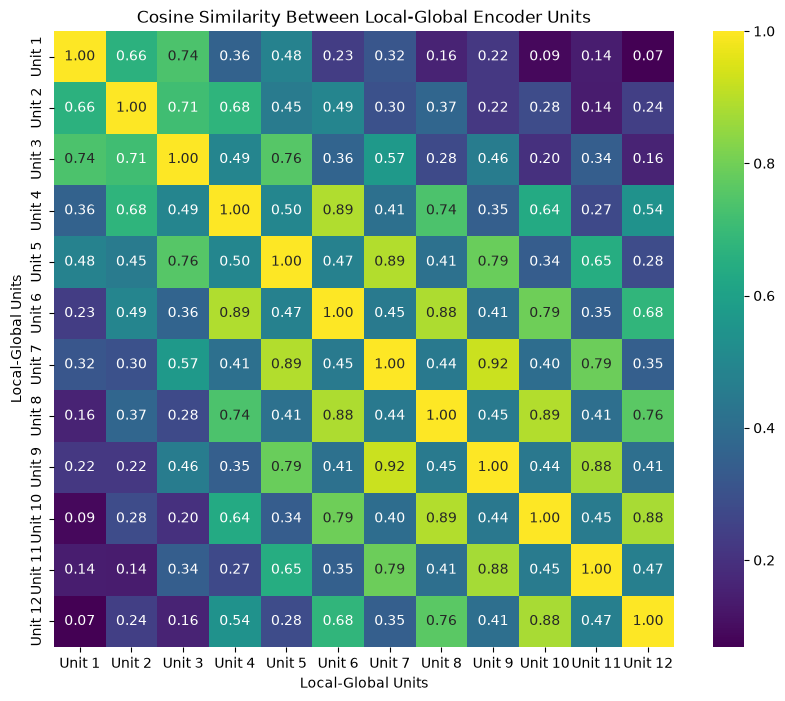

--- Pruning Candidates (Similarity Threshold: 0.85) ---
Indices of Units to prune (0-indexed): [5, 6, 9, 10]
Original Encoder Layers to prune: [10, 11, 12, 13, 18, 19, 20, 21]


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.nn.functional import cosine_similarity
from PrithviWxC.rollout import rollout_iter # Make sure this is imported

# ==========================================
# 1. Extract Hidden States via Hooks
# ==========================================
# Locate the 25 encoder layers dynamically.
encoder_blocks = None
for name, module in model.named_modules():
    if isinstance(module, torch.nn.ModuleList) and len(module) == 25:
        encoder_blocks = module
        break

if encoder_blocks is None:
    encoder_blocks = model.blocks if hasattr(model, "blocks") else model.encoder 

unit_outputs = []

def get_activation():
    """Hook to capture the output of a specific layer."""
    def hook(module, input, output):
        if isinstance(output, tuple):
            unit_outputs.append(output[0].detach())
        else:
            unit_outputs.append(output.detach())
    return hook

handles = []
# The first 24 layers form 12 (Local, Global) combined units.
# The 25th layer (index 24, Local) is left exactly as it is.
for i in range(1, 24, 2):
    handles.append(encoder_blocks[i].register_forward_hook(get_activation()))

# ==========================================
# 2. Calculate Similarity Matrix for 12 Units
# ==========================================
dataset_similarity_matrix = torch.zeros((12, 12)).to(device)
cnt = 0

model.eval()

# Process the dataset to get average cosine similarities
for data in dataset:
    unit_outputs.clear()  # Reset for the new sample

    # Preprocess the data sample
    batch = preproc([data], padding)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(device)

    with torch.no_grad():
        # FIX: Use rollout_iter restricted to 1 step instead of model(batch).
        # This safely unpacks the rollout dataset sequence and provides 
        # the model with the exact dictionary keys it expects (including 'y').
        out = rollout_iter(1, model, batch)

    # unit_outputs contains exactly 12 tensors for the 12 units.
    # Shape becomes: [12, batch_size=1, seq_len, embed_dim]
    hidden_states = torch.stack(unit_outputs)
    
    # Flatten spatial/sequence dimensions: [12, total_tokens, embed_dim]
    decoder_hidden_states = hidden_states.view(12, -1, hidden_states.shape[-1])
    
    similarity_matrix = torch.zeros((12, 12)).to(device)

    for layer_i in range(12):
        for layer_j in range(layer_i, 12):
            sim = cosine_similarity(
                decoder_hidden_states[layer_i],
                decoder_hidden_states[layer_j],
                dim=-1
            )
            # Average similarity across all tokens for this specific pair
            avg_similarity = sim.mean().item()
            
            similarity_matrix[layer_i, layer_j] = avg_similarity
            similarity_matrix[layer_j, layer_i] = avg_similarity

    dataset_similarity_matrix += similarity_matrix
    cnt += 1

# Average over all processed samples
print(f"Processed {cnt} samples. Averaging similarity matrix...")
dataset_similarity_matrix /= cnt

# Clean up hooks to free memory
for handle in handles:
    handle.remove()

# ==========================================
# 3. Visualize Similarity Heatmap
# ==========================================
sim_matrix_np = dataset_similarity_matrix.cpu().numpy()

plt.figure(figsize=(10, 8))
unit_labels = [f"Unit {i+1}" for i in range(12)]

sns.heatmap(
    sim_matrix_np, 
    annot=True, 
    fmt=".2f", 
    cmap="viridis",
    xticklabels=unit_labels, 
    yticklabels=unit_labels
)

plt.title("Cosine Similarity Between Local-Global Encoder Units")
plt.xlabel("Local-Global Units")
plt.ylabel("Local-Global Units")
plt.show()

# ==========================================
# 4. Determine Units to Prune (Threshold = 0.85)
# ==========================================
thres = 0.85
ind_unit_to_del = set()

# Iteratively check and mark redundant units for deletion
for i in range(len(sim_matrix_np)):
    if i in ind_unit_to_del:
        continue
    for k in range(i + 1, len(sim_matrix_np)):
        if k in ind_unit_to_del:
            continue
        # If similarity surpasses the threshold, flag 'k' for deletion
        if sim_matrix_np[i][k] >= thres:
            ind_unit_to_del.add(k)

print(f"--- Pruning Candidates (Similarity Threshold: {thres}) ---")
print("Indices of Units to prune (0-indexed):", sorted(ind_unit_to_del))

# Translate the unit indices back to their original layer indices in the 25-block encoder
layers_to_delete = []
for unit_idx in sorted(ind_unit_to_del):
    local_layer = unit_idx * 2
    global_layer = unit_idx * 2 + 1
    layers_to_delete.extend([local_layer, global_layer])

print("Original Encoder Layers to prune:", layers_to_delete)

In [2]:
import copy
from pathlib import Path
import torch
import torch.nn as nn
from torch.nn.functional import cosine_similarity

# ==============================================================================
# USER CONFIGURATION: Set your Threshold and Output Filename here
# ==============================================================================
THRESHOLD = 0.75  
PRUNED_WEIGHTS_FILENAME = "prithvi_wxc_rollout_pruned_75.pt"
# ==============================================================================

print(f"Running pipeline with Threshold: {THRESHOLD}")
print(f"Target Save Filename: {PRUNED_WEIGHTS_FILENAME}\n")

# Utility to prevent batch mutation errors between rollout calls
def get_fresh_batch(b):
    fresh = {}
    for k, v in b.items():
        if isinstance(v, torch.Tensor):
            fresh[k] = v.clone()
        else:
            fresh[k] = copy.deepcopy(v)
    return fresh

# ==========================================
# 1. Locate Encoder & Register Hooks
# ==========================================
encoder_blocks = None
for name, module in model.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        encoder_blocks = module
        break

if encoder_blocks is None:
    encoder_blocks = model.blocks if hasattr(model, "blocks") else model.encoder

unit_outputs = []

def get_activation():
    def hook(module, input, output):
        # Limit to 12 activations to capture exactly one timestep pass
        if len(unit_outputs) < 12:
            if isinstance(output, tuple):
                unit_outputs.append(output[0].detach())
            else:
                unit_outputs.append(output.detach())
    return hook

handles = []
# Attach hooks to global attention layers (indices 1, 3, 5, ..., 23)
for i in range(1, 24, 2):
    handles.append(encoder_blocks[i].register_forward_hook(get_activation()))

# ==========================================
# 2. Calculate Similarity Matrix
# ==========================================
print("Calculating layer similarity metrics...")
model.eval()
unit_outputs.clear()

with torch.no_grad():
    # Pass a CLONED batch so the original is not consumed/corrupted by rollout_iter
    batch_sim = get_fresh_batch(batch)
    _ = rollout_iter(1, model, batch_sim)

# Clean up hooks immediately
for handle in handles:
    handle.remove()

if len(unit_outputs) != 12:
    print(f"Warning: Expected 12 unit outputs, got {len(unit_outputs)}")

# Ensure we only process exactly 12 states (1 per global layer)
unit_outputs = unit_outputs[:12]
hidden_states = torch.stack(unit_outputs)

# Flatten spatial/channel dims to compute similarity across layers
decoder_hidden_states = hidden_states.view(12, -1, hidden_states.shape[-1])

similarity_matrix = torch.zeros((12, 12)).to(device)
for layer_i in range(12):
    for layer_j in range(layer_i, 12):
        sim = cosine_similarity(
            decoder_hidden_states[layer_i],
            decoder_hidden_states[layer_j],
            dim=-1,
        )
        avg_sim = sim.mean().item()
        similarity_matrix[layer_i, layer_j] = avg_sim
        similarity_matrix[layer_j, layer_i] = avg_sim

sim_matrix_np = similarity_matrix.cpu().numpy()

# ==========================================
# 3. Determine Units to Prune
# ==========================================
ind_unit_to_del = set()

for i in range(len(sim_matrix_np)):
    if i in ind_unit_to_del:
        continue
    for k in range(i + 1, len(sim_matrix_np)):
        if k in ind_unit_to_del:
            continue
        if sim_matrix_np[i][k] >= THRESHOLD:
            ind_unit_to_del.add(k)

units_to_delete = sorted(list(ind_unit_to_del), reverse=True)
print(f"Units to prune (0-indexed): {sorted(list(ind_unit_to_del))}")

# ==========================================
# 4. Prune the Units & Save New Weights
# ==========================================
model_pruned = copy.deepcopy(model)

encoder_parent = None
encoder_attr_name = None
encoder_blocks_pruned = None

for name, module in model_pruned.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        parts = name.split(".")
        parent = model_pruned
        for part in parts[:-1]:
            parent = getattr(parent, part)
        encoder_parent = parent
        encoder_attr_name = parts[-1]
        encoder_blocks_pruned = module
        break

if encoder_blocks_pruned is not None and len(units_to_delete) > 0:
    blocks_list = list(encoder_blocks_pruned)

    for unit_idx in units_to_delete:
        global_layer_idx = unit_idx * 2 + 1
        local_layer_idx = unit_idx * 2
        del blocks_list[global_layer_idx]
        del blocks_list[local_layer_idx]

    setattr(encoder_parent, encoder_attr_name, nn.ModuleList(blocks_list))

    num_deleted_layers = len(units_to_delete) * 2
    model_pruned.n_blocks_encoder -= num_deleted_layers

    # Ensure weights directory exists
    save_path = Path("../data/weights") / PRUNED_WEIGHTS_FILENAME
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    torch.save(model_pruned.state_dict(), save_path)
    print(f"Successfully pruned {num_deleted_layers} individual transformer layers.")
    print(f"Pruned model saved to: {save_path}\n")

elif len(units_to_delete) == 0:
    print(f"No units met the similarity threshold of {THRESHOLD}. No layers were pruned.\n")
else:
    print("Error: Could not locate the 25-layer encoder ModuleList.\n")

# ==========================================
# 5. Metrics & Prediction Evaluation
# ==========================================
def latitude_weighted_rmse(pred, target):
    # Dynamic spatial dimensions to handle both 4D and 5D rollout tensors safely
    spatial_dims = (-2, -1)
    H = pred.shape[-2]
    
    lat = torch.linspace(-90, 90, H, device=pred.device)
    view_shape = [1] * pred.dim()
    view_shape[-2] = H
    w = torch.cos(torch.deg2rad(lat)).view(*view_shape)
    w_norm = w / w.mean()

    error_sq = (pred - target) ** 2
    weighted_mse = (error_sq * w_norm).mean(dim=spatial_dims)
    rmse = torch.sqrt(weighted_mse)
    return rmse.mean().item()

def anomaly_correlation_coefficient(pred, target):
    spatial_dims = (-2, -1)
    H = pred.shape[-2]
    
    lat = torch.linspace(-90, 90, H, device=pred.device)
    view_shape = [1] * pred.dim()
    view_shape[-2] = H
    w = torch.cos(torch.deg2rad(lat)).view(*view_shape)
    w_norm = w / w.mean()

    pred_mean = (pred * w_norm).mean(dim=spatial_dims, keepdim=True)
    target_mean = (target * w_norm).mean(dim=spatial_dims, keepdim=True)

    pred_anom = pred - pred_mean
    target_anom = target - target_mean

    cov = (pred_anom * target_anom * w_norm).mean(dim=spatial_dims)
    var_pred = (pred_anom**2 * w_norm).mean(dim=spatial_dims)
    var_target = (target_anom**2 * w_norm).mean(dim=spatial_dims)

    acc = cov / torch.sqrt(var_pred * var_target)
    return acc.mean().item()


print("Running autoregressive rollout for evaluation...")
with torch.no_grad():
    model.eval()
    
    # Clone batch for original model eval
    batch_eval_orig = get_fresh_batch(batch)
    out_original = rollout_iter(dataset.nsteps, model, batch_eval_orig)

    if len(units_to_delete) > 0:
        model_pruned.eval()
        # Clone batch for pruned model eval
        batch_eval_pruned = get_fresh_batch(batch)
        out_pruned = rollout_iter(dataset.nsteps, model_pruned, batch_eval_pruned)
    else:
        out_pruned = out_original

y_true = batch.get("target")

print("\n================= Evaluation Results =================")
if y_true is not None:
    y_true = y_true.to(device)
    
    # Trim y_true time dimension if it's longer than rollout steps
    if y_true.dim() == 5 and y_true.shape[1] > out_original.shape[1]:
        y_true = y_true[:, :out_original.shape[1]]

    rmse_orig = latitude_weighted_rmse(out_original, y_true)
    acc_orig = anomaly_correlation_coefficient(out_original, y_true)

    rmse_pruned = latitude_weighted_rmse(out_pruned, y_true)
    acc_pruned = anomaly_correlation_coefficient(out_pruned, y_true)

    print("Comparison against Ground Truth:")
    print(f"  • Original Model -> ACC: {acc_orig:.4f} | Lat-Weighted RMSE: {rmse_orig:.4f}")
    print(f"  • Pruned Model   -> ACC: {acc_pruned:.4f} | Lat-Weighted RMSE: {rmse_pruned:.4f}")
else:
    rmse_diff = latitude_weighted_rmse(out_pruned, out_original)
    acc_diff = anomaly_correlation_coefficient(out_pruned, out_original)

    print("Ground Truth not detected. Comparing Pruned Predictions vs Original Predictions:")
    print(f"  • Prediction Similarity (ACC): {acc_diff:.4f}")
    print(f"  • Prediction Divergence (RMSE): {rmse_diff:.4f}")
print("=======================================================")

Running pipeline with Threshold: 0.75
Target Save Filename: prithvi_wxc_rollout_pruned_75.pt

Calculating layer similarity metrics...
Units to prune (0-indexed): [4, 5, 8, 9, 10, 11]
Successfully pruned 12 individual transformer layers.
Pruned model saved to: ../data/weights/prithvi_wxc_rollout_pruned_75.pt

Running autoregressive rollout for evaluation...

================= Evaluation Results =================
Ground Truth not detected. Comparing Pruned Predictions vs Original Predictions:
  • Prediction Similarity (ACC): 0.8698
  • Prediction Divergence (RMSE): 17.1186


In [2]:
import copy
from pathlib import Path
import torch
import torch.nn as nn
from torch.nn.functional import cosine_similarity

# ==============================================================================
# USER CONFIGURATION
# ==============================================================================
THRESHOLD = 0.75  
PRUNED_WEIGHTS_FILENAME = "prithvi_wxc_rollout_pruned_75.pt"
HOURS_PER_STEP = 6  # Adjust this if your dataset rollout step is different (e.g., 12)
# ==============================================================================

print(f"Running pipeline with Threshold: {THRESHOLD}")
print(f"Target Save Filename: {PRUNED_WEIGHTS_FILENAME}\n")

# Utility to prevent batch mutation errors between rollout calls
def get_fresh_batch(b):
    fresh = {}
    for k, v in b.items():
        if isinstance(v, torch.Tensor):
            fresh[k] = v.clone()
        else:
            fresh[k] = copy.deepcopy(v)
    return fresh

# ==========================================
# 1. Locate Encoder & Register Hooks
# ==========================================
encoder_blocks = None
for name, module in model.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        encoder_blocks = module
        break

if encoder_blocks is None:
    encoder_blocks = model.blocks if hasattr(model, "blocks") else model.encoder

unit_outputs = []

def get_activation():
    def hook(module, input, output):
        # Limit to 12 activations to capture exactly one timestep pass
        if len(unit_outputs) < 12:
            if isinstance(output, tuple):
                unit_outputs.append(output[0].detach())
            else:
                unit_outputs.append(output.detach())
    return hook

handles = []
# Attach hooks to global attention layers (indices 1, 3, 5, ..., 23)
for i in range(1, 24, 2):
    handles.append(encoder_blocks[i].register_forward_hook(get_activation()))

# ==========================================
# 2. Calculate Similarity Matrix
# ==========================================
print("Calculating layer similarity metrics...")
model.eval()
unit_outputs.clear()

with torch.no_grad():
    # Pass a CLONED batch so the original is not consumed/corrupted by rollout_iter
    batch_sim = get_fresh_batch(batch)
    _ = rollout_iter(1, model, batch_sim)

# Clean up hooks immediately
for handle in handles:
    handle.remove()

if len(unit_outputs) != 12:
    print(f"Warning: Expected 12 unit outputs, got {len(unit_outputs)}")

# Ensure we only process exactly 12 states (1 per global layer)
unit_outputs = unit_outputs[:12]
hidden_states = torch.stack(unit_outputs)

# Flatten spatial/channel dims to compute similarity across layers
decoder_hidden_states = hidden_states.view(12, -1, hidden_states.shape[-1])

similarity_matrix = torch.zeros((12, 12)).to(device)
for layer_i in range(12):
    for layer_j in range(layer_i, 12):
        sim = cosine_similarity(
            decoder_hidden_states[layer_i],
            decoder_hidden_states[layer_j],
            dim=-1,
        )
        avg_sim = sim.mean().item()
        similarity_matrix[layer_i, layer_j] = avg_sim
        similarity_matrix[layer_j, layer_i] = avg_sim

sim_matrix_np = similarity_matrix.cpu().numpy()

# ==========================================
# 3. Determine Units to Prune
# ==========================================
ind_unit_to_del = set()

for i in range(len(sim_matrix_np)):
    if i in ind_unit_to_del:
        continue
    for k in range(i + 1, len(sim_matrix_np)):
        if k in ind_unit_to_del:
            continue
        if sim_matrix_np[i][k] >= THRESHOLD:
            ind_unit_to_del.add(k)

units_to_delete = sorted(list(ind_unit_to_del), reverse=True)
print(f"Units to prune (0-indexed): {sorted(list(ind_unit_to_del))}")

# ==========================================
# 4. Prune the Units & Save New Weights
# ==========================================
model_pruned = copy.deepcopy(model)

encoder_parent = None
encoder_attr_name = None
encoder_blocks_pruned = None

for name, module in model_pruned.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        parts = name.split(".")
        parent = model_pruned
        for part in parts[:-1]:
            parent = getattr(parent, part)
        encoder_parent = parent
        encoder_attr_name = parts[-1]
        encoder_blocks_pruned = module
        break

if encoder_blocks_pruned is not None and len(units_to_delete) > 0:
    blocks_list = list(encoder_blocks_pruned)

    for unit_idx in units_to_delete:
        global_layer_idx = unit_idx * 2 + 1
        local_layer_idx = unit_idx * 2
        del blocks_list[global_layer_idx]
        del blocks_list[local_layer_idx]

    setattr(encoder_parent, encoder_attr_name, nn.ModuleList(blocks_list))

    num_deleted_layers = len(units_to_delete) * 2
    model_pruned.n_blocks_encoder -= num_deleted_layers

    # Ensure weights directory exists
    save_path = Path("../data/weights") / PRUNED_WEIGHTS_FILENAME
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    torch.save(model_pruned.state_dict(), save_path)
    print(f"Successfully pruned {num_deleted_layers} individual transformer layers.")
    print(f"Pruned model saved to: {save_path}\n")

elif len(units_to_delete) == 0:
    print(f"No units met the similarity threshold of {THRESHOLD}. No layers were pruned.\n")
else:
    print("Error: Could not locate the 25-layer encoder ModuleList.\n")

# ==========================================
# 5. Temporal Metrics & Prediction Evaluation
# ==========================================
def latitude_weighted_rmse(pred, target):
    # Dynamic spatial dimensions to handle both 4D and 5D tensors safely
    spatial_dims = (-2, -1)
    H = pred.shape[-2]
    
    lat = torch.linspace(-90, 90, H, device=pred.device)
    view_shape = [1] * pred.dim()
    view_shape[-2] = H
    w = torch.cos(torch.deg2rad(lat)).view(*view_shape)
    w_norm = w / w.mean()

    error_sq = (pred - target) ** 2
    weighted_mse = (error_sq * w_norm).mean(dim=spatial_dims)
    rmse = torch.sqrt(weighted_mse)
    return rmse.mean().item()

def anomaly_correlation_coefficient(pred, target):
    spatial_dims = (-2, -1)
    H = pred.shape[-2]
    
    lat = torch.linspace(-90, 90, H, device=pred.device)
    view_shape = [1] * pred.dim()
    view_shape[-2] = H
    w = torch.cos(torch.deg2rad(lat)).view(*view_shape)
    w_norm = w / w.mean()

    pred_mean = (pred * w_norm).mean(dim=spatial_dims, keepdim=True)
    target_mean = (target * w_norm).mean(dim=spatial_dims, keepdim=True)

    pred_anom = pred - pred_mean
    target_anom = target - target_mean

    cov = (pred_anom * target_anom * w_norm).mean(dim=spatial_dims)
    var_pred = (pred_anom**2 * w_norm).mean(dim=spatial_dims)
    var_target = (target_anom**2 * w_norm).mean(dim=spatial_dims)

    acc = cov / torch.sqrt(var_pred * var_target)
    return acc.mean().item()

print("Running autoregressive rollout for evaluation...")
with torch.no_grad():
    model.eval()
    batch_eval_orig = get_fresh_batch(batch)
    out_original = rollout_iter(dataset.nsteps, model, batch_eval_orig)

    if len(units_to_delete) > 0:
        model_pruned.eval()
        batch_eval_pruned = get_fresh_batch(batch)
        out_pruned = rollout_iter(dataset.nsteps, model_pruned, batch_eval_pruned)
    else:
        out_pruned = out_original

y_true = batch.get("target")

print("\n================= Temporal Evaluation Results =================")
# Define the milestones we want to evaluate
eval_milestones = {
    "12 Hours": 12,
    "1 Day": 24,
    "3 Days": 72,
    "7 Days": 168
}

max_steps_available = out_original.shape[1]

for label, target_hour in eval_milestones.items():
    # Calculate which step index this hour corresponds to
    # e.g., if step is 6 hours: 12h -> idx 1, 24h -> idx 3
    step_idx = int(target_hour / HOURS_PER_STEP) - 1
    
    # Verify we actually rolled out this far
    if step_idx >= max_steps_available or step_idx < 0:
        print(f"\n--- {label} Lead Time ---")
        print(f"  [!] Skipped: Requires step {step_idx+1}, but output only has {max_steps_available} steps.")
        print(f"      (Increase your time_range or dataset.nsteps in Cell 1 to evaluate this timeframe)")
        continue

    # Extract just this specific timestep (Resulting shape: B, C, H, W)
    pred_orig_step = out_original[:, step_idx]
    pred_pruned_step = out_pruned[:, step_idx]

    print(f"\n--- {label} Lead Time (Step {step_idx+1}) ---")

    if y_true is not None:
        y_true = y_true.to(device)
        
        # Verify y_true has ground truth data for this step
        if step_idx < y_true.shape[1]:
            y_true_step = y_true[:, step_idx]
            
            rmse_orig = latitude_weighted_rmse(pred_orig_step, y_true_step)
            acc_orig = anomaly_correlation_coefficient(pred_orig_step, y_true_step)
            
            rmse_pruned = latitude_weighted_rmse(pred_pruned_step, y_true_step)
            acc_pruned = anomaly_correlation_coefficient(pred_pruned_step, y_true_step)
            
            print(f"  • Original Model -> ACC: {acc_orig:.4f} | Lat-Weighted RMSE: {rmse_orig:.4f}")
            print(f"  • Pruned Model   -> ACC: {acc_pruned:.4f} | Lat-Weighted RMSE: {rmse_pruned:.4f}")
        else:
             print(f"  [!] Skipped Ground Truth: 'y_true' does not contain data for step {step_idx+1}.")
    else:
        # Compare pruned to original if no ground truth is available
        rmse_diff = latitude_weighted_rmse(pred_pruned_step, pred_orig_step)
        acc_diff = anomaly_correlation_coefficient(pred_pruned_step, pred_orig_step)
        
        print("  Ground Truth not detected. Comparing Pruned vs Original Predictions:")
        print(f"  • Similarity (ACC): {acc_diff:.4f} | Divergence (RMSE): {rmse_diff:.4f}")

print("\n===============================================================")

Running pipeline with Threshold: 0.75
Target Save Filename: prithvi_wxc_rollout_pruned_75.pt

Calculating layer similarity metrics...
Units to prune (0-indexed): [4, 5, 8, 9, 10, 11]
Successfully pruned 12 individual transformer layers.
Pruned model saved to: ../data/weights/prithvi_wxc_rollout_pruned_75.pt

Running autoregressive rollout for evaluation...

================= Temporal Evaluation Results =================

--- 12 Hours Lead Time (Step 2) ---
  Ground Truth not detected. Comparing Pruned vs Original Predictions:
  • Similarity (ACC): 0.9960 | Divergence (RMSE): 0.0206

--- 1 Day Lead Time (Step 4) ---
  Ground Truth not detected. Comparing Pruned vs Original Predictions:
  • Similarity (ACC): 0.9999 | Divergence (RMSE): 0.0107

--- 3 Days Lead Time (Step 12) ---
  Ground Truth not detected. Comparing Pruned vs Original Predictions:
  • Similarity (ACC): 0.9939 | Divergence (RMSE): 37.8488

--- 7 Days Lead Time (Step 28) ---
  Ground Truth not detected. Comparing Pruned vs

In [3]:
import os

# Define the paths to your four weight files
original_weights_path = "../data/weights/prithvi.wxc.rollout.2300m.v1.pt"
pruned_75 = "../data/weights/prithvi_wxc_rollout_pruned_75.pt"
# Create a dictionary for easy iteration
model_files = {
    "Original Checkpoint (FP32 + Metadata)": original_weights_path,
    "pruned (Threshold 0.75)": pruned_75,
}

print("=" * 65)
print(f"{'MODEL WEIGHT FILE SIZES':^65}")
print("=" * 65)

for name, path in model_files.items():
    if os.path.exists(path):
        # Get size in bytes and convert to Gigabytes (GB)
        size_bytes = os.path.getsize(path)
        size_gb = size_bytes / (1024 ** 3)
        print(f"{name:<40} : {size_gb:>5.2f} GB")
    else:
        print(f"{name:<40} : [FILE NOT FOUND]")

print("=" * 65)

                     MODEL WEIGHT FILE SIZES                     
Original Checkpoint (FP32 + Metadata)    : 26.49 GB
pruned (Threshold 0.75)                  :  5.32 GB
